# Crop Yield Prediction - Mining & Clustering

## ⚒️ Khai Phá Dữ Liệu & Phân Cụm

Notebook này thực hiện:
1. **Association Rule Mining** - Tìm các quy tắc liên kết
2. **KMeans Clustering** - Phân cụm KMeans
3. **DBSCAN Clustering** - Phân cụm DBSCAN

---

In [1]:
import sys
from pathlib import Path

# Thêm src vào path để import modules
src_path = Path('../src')
sys.path.insert(0, str(src_path.absolute()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Import modules
from data.loader import DataLoader
from mining.association import AssociationRuleMining
from mining.clustering import ClusteringAnalysis

print("✓ Đã import tất cả thư viện")

✓ Đã import tất cả thư viện


In [2]:
# Tải dữ liệu (CLEANED DATA)
loader = DataLoader(data_dir="../data/raw/cleaned", use_cleaned=True)
df_merged, _ = loader.get_complete_dataset()

# Lấy sample để phân tích nhanh hơn
df_sample = df_merged.sample(n=min(500, len(df_merged)), random_state=42)

print(f"📊 Dataset shape: {df_sample.shape}")
print(f"\nColumns: {df_sample.columns.tolist()[:5]}...")


📊 BẮT ĐẦU TẢI DỮ LIỆU
📂 Đang đọc file (CLEANED): yield_cleaned.csv...
   ✓ Thành công! Shape: (56717, 12)
📂 Đang đọc file (CLEANED): pesticides_cleaned.csv...
   ✓ Thành công! Shape: (4349, 7)
📂 Đang đọc file (CLEANED): rainfall_cleaned.csv...
   ✓ Thành công! Shape: (5947, 3)
📂 Đang đọc file (CLEANED): temp_cleaned.csv...
   ✓ Thành công! Shape: (68764, 3)

✓ Đã tải 4 file dữ liệu!

🔗 KẾT HỢP CÁC DATASET
   Bắt đầu: yield (56717, 3)
   Sau merge pesticides: (24153, 4)
   Sau merge rainfall: (18949, 5)
   Sau merge temperature: (28242, 6)

✓ Kết hợp xong! Shape cuối cùng: (28242, 6)
📊 Dataset shape: (500, 6)

Columns: ['Year', 'Area', 'Yield', 'Pesticides', 'Rainfall']...


## 1. Association Rule Mining

In [3]:
# Khởi tạo Association Rule Mining
mining = AssociationRuleMining()

# Lấy numeric features
numeric_features = df_sample.select_dtypes(include=[np.number]).columns.tolist()
X_numeric = df_sample[numeric_features].dropna()

print(f"📊 Numeric features: {len(numeric_features)}")
print(f"Rows: {len(X_numeric)}")

📊 Numeric features: 5
Rows: 500


In [4]:
# Rời rạc hóa các features
df_discrete = mining.discretize_features(X_numeric, n_bins=4, strategy='quantile')

print(f"\n✓ Data đã được rời rạc hóa")
print(f"Shape: {df_discrete.shape}")
print(f"\nSample data:")
display(df_discrete.head())


📊 RỜI RẠC HÓA DỮ LIỆU

   Số features: 5
   Số bins: 4
   Strategy: quantile
   ✓ Year: discretized thành 4 bins
   ✓ Yield: discretized thành 4 bins
   ✓ Pesticides: discretized thành 4 bins
   ✓ Rainfall: discretized thành 4 bins
   ✓ Temperature: discretized thành 4 bins

✓ Data đã được rời rạc hóa
Shape: (500, 5)

Sample data:


,Year,Yield,Pesticides,Rainfall,Temperature
25564,3,2,2,1,1
18113,1,0,0,2,1
25607,3,2,2,1,0
6815,2,3,3,3,3
18144,1,2,0,2,1


In [5]:
# Tạo itemsets
itemset_matrix = mining.create_itemsets(df_discrete)

print(f"\n✓ Itemsets đã tạo")
print(f"Matrix shape: {itemset_matrix.shape}")
print(f"\nSample items: {itemset_matrix.columns[:5].tolist()}")


🛒 TẠO ITEMSETS

   Số features: 5
   Items được tạo: 20
   Transactions: 500
   Matrix shape: (500, 20)

✓ Itemsets đã tạo
Matrix shape: (500, 20)

Sample items: ['Year=0', 'Year=1', 'Year=2', 'Year=3', 'Yield=0']


In [6]:
# Tìm frequent itemsets
frequent_itemsets = mining.find_frequent_itemsets(
    itemset_matrix,
    min_support=0.2
)

print(f"\n✓ Frequent itemsets tìm được: {len(frequent_itemsets)}")


🔍 APRIORI ALGORITHM - TÌM ITEMSETS THƯỜNG XUYÊN

   Min support: 0.2
   Đang chạy Apriori...

   ✓ Tìm được 20 frequent itemsets

   Top 15 Frequent Itemsets:
    1. ['Rainfall=2'] → support: 0.2920
    2. ['Year=3'] → support: 0.2740
    3. ['Year=2'] → support: 0.2580
    4. ['Year=1'] → support: 0.2540
    5. ['Pesticides=3'] → support: 0.2520
    6. ['Temperature=3'] → support: 0.2500
    7. ['Temperature=0'] → support: 0.2500
    8. ['Yield=0'] → support: 0.2500
    9. ['Yield=1'] → support: 0.2500
   10. ['Yield=2'] → support: 0.2500
   11. ['Yield=3'] → support: 0.2500
   12. ['Pesticides=0'] → support: 0.2500
   13. ['Pesticides=1'] → support: 0.2500
   14. ['Temperature=2'] → support: 0.2500
   15. ['Temperature=1'] → support: 0.2500

✓ Frequent itemsets tìm được: 20


In [7]:
# Tạo association rules
if len(frequent_itemsets) > 0:
    rules = mining.generate_rules(
        min_confidence=0.3,
        min_lift=1.0
    )
    
    if len(rules) > 0:
        # Hiển thị rules
        rules_summary = mining.get_rules_summary()
        
        print(f"\n📋 Association Rules Summary:")
        display(rules_summary.head(10))
else:
    print("No frequent itemsets found")


🔗 TẠO ASSOCIATION RULES

   Min confidence: 0.3
   Min lift: 1.0
   Đang tạo rules...

   ✓ Tìm được 0 rules

   Metrics Statistics:
   • Support:    min=nan, max=nan
   • Confidence: min=nan, max=nan
   • Lift:       min=nan, max=nan


## 2. Clustering Analysis - KMeans

In [8]:
# Khởi tạo clustering
clustering = ClusteringAnalysis()

# Chuẩn bị dữ liệu
X_scaled = clustering.prepare_data(X_numeric)

print(f"✓ Dữ liệu đã chuẩn bị")
print(f"Shape: {X_scaled.shape}")


📊 CHUẨN BỊ DỮ LIỆU CHO CLUSTERING

   Input shape: (500, 5)
   ✓ Dữ liệu đã scale: (500, 5)
   ✓ Mean: [ 0. -0. -0.]
   ✓ Std: [1. 1. 1.]
✓ Dữ liệu đã chuẩn bị
Shape: (500, 5)



📈 ELBOW METHOD - TÌM SỐ CLUSTER TỐI ƯU

   Test K từ 1 đến 10...
   K= 1: Inertia = 2500.00
   K= 2: Inertia = 2030.41
   K= 3: Inertia = 1700.56
   K= 4: Inertia = 1346.12
   K= 5: Inertia = 1086.83
   K= 6: Inertia = 888.44
   K= 7: Inertia = 814.64
   K= 8: Inertia = 750.80
   K= 9: Inertia = 695.54
   K=10: Inertia = 648.88

   💡 Để chọn K tối ưu, hãy tìm điểm 'elbow' trong biểu đồ


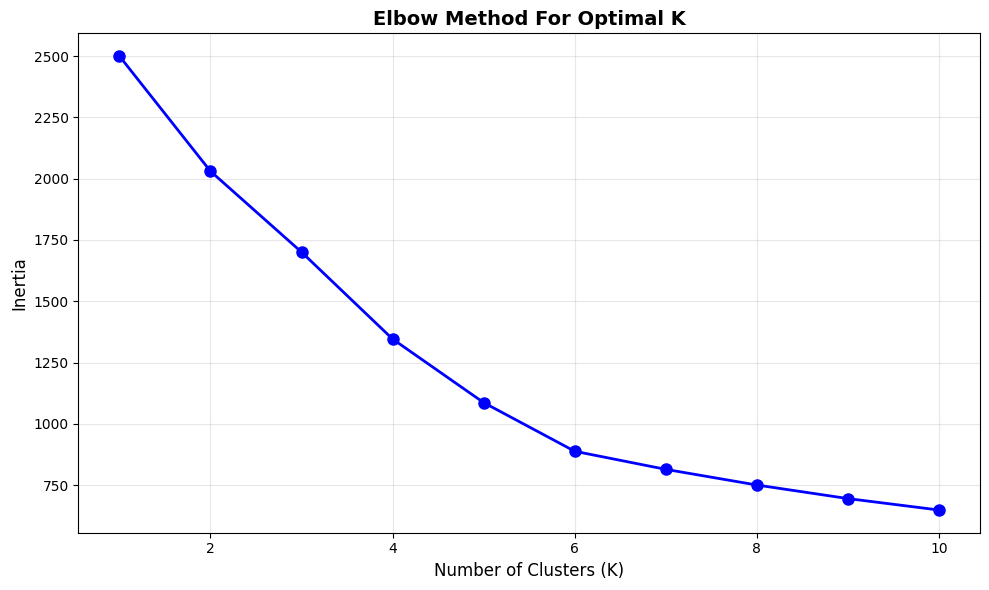

✓ Elbow plot đã vẽ


In [9]:
# Elbow method để tìm K tối ưu
inertias = clustering.elbow_method(X_scaled, max_k=10, n_init=10)

# Vẽ elbow curve
fig, ax = plt.subplots(figsize=(10, 6))

k_values = list(inertias.keys())
inertia_values = list(inertias.values())

ax.plot(k_values, inertia_values, 'b-o', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_title('Elbow Method For Optimal K', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Elbow plot đã vẽ")

In [10]:
# KMeans clustering với K=3
kmeans_labels, kmeans_model = clustering.kmeans_clustering(
    X_scaled,
    n_clusters=3,
    n_init=10
)

print(f"\n✓ KMeans clustering hoàn tất")


🎯 KMEANS CLUSTERING

   Số clusters: 3
   Input shape: (500, 5)
   Đang huấn luyện...

   ✓ Hoàn thành!
   • Inertia: 1700.56
   • Silhouette Score: 0.2100

   Phân bố Clusters:
   • Cluster 0: 234 mẫu (46.8%)
   • Cluster 1: 179 mẫu (35.8%)
   • Cluster 2: 87 mẫu (17.4%)

✓ KMeans clustering hoàn tất


In [11]:
# Phân tích clusters
cluster_profiles = clustering.analyze_clusters_kmeans(X_numeric)

print("\n📊 Cluster Profiles:")
display(cluster_profiles)


📊 PHÂN TÍCH ĐẶC ĐIỂM CỦA TỪNG CLUSTER (KMeans)

   Phân tích 3 clusters:

   Cluster 0 (n=234):
      • Year: 2000.38 ± 7.32
      • Yield: 45892.19 ± 42905.11
      • Pesticides: 26047.51 ± 32969.07
      • Rainfall: 1559.93 ± 780.59
      • Temperature: 24.88 ± 2.93

   Cluster 1 (n=179):
      • Year: 2002.40 ± 7.10
      • Yield: 49929.60 ± 37704.46
      • Pesticides: 23012.97 ± 22490.40
      • Rainfall: 667.81 ± 352.16
      • Temperature: 14.81 ± 5.63

   Cluster 2 (n=87):
      • Year: 2003.53 ± 6.91
      • Yield: 213431.49 ± 96311.76
      • Pesticides: 90417.99 ± 111572.76
      • Rainfall: 1044.34 ± 518.59
      • Temperature: 21.59 ± 5.06

📊 Cluster Profiles:


,Cluster,Size,Year_mean,Yield_mean,Pesticides_mean,Rainfall_mean,Temperature_mean
0,0,234,2000.376068,45892.188034,26047.508120,1559.927350,24.879188
1,1,179,2002.396648,49929.603352,23012.970615,667.810056,14.814581
2,2,87,2003.528736,213431.494253,90417.987586,1044.344828,21.589655


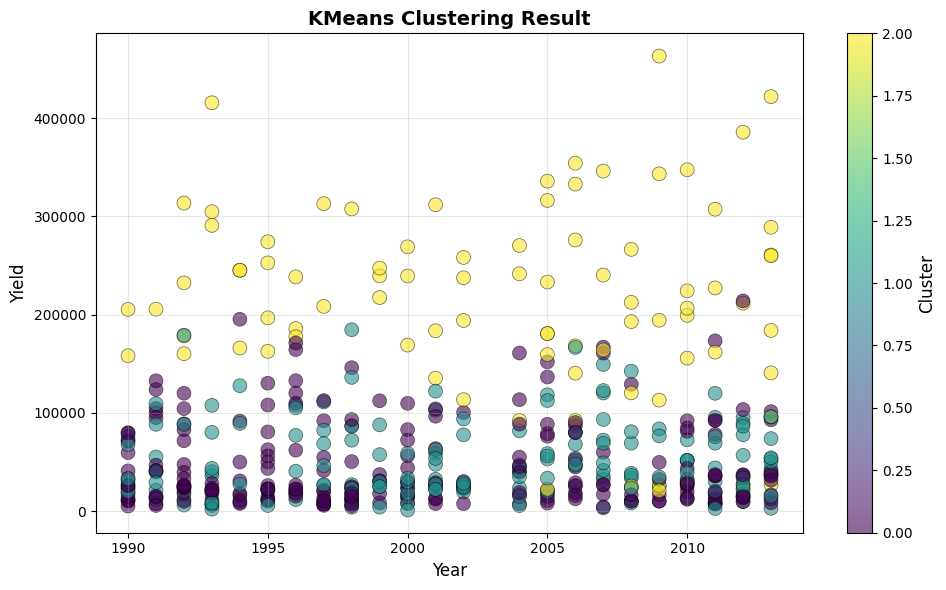

✓ Cluster plot đã vẽ


In [12]:
# Vẽ clusters (scatter plot của 2 features đầu tiên)
fig, ax = plt.subplots(figsize=(10, 6))

X_numeric_reset = X_numeric.reset_index(drop=True)
feature_x = X_numeric.columns[0]
feature_y = X_numeric.columns[1] if len(X_numeric.columns) > 1 else X_numeric.columns[0]

scatter = ax.scatter(X_numeric_reset[feature_x], X_numeric_reset[feature_y],
                     c=kmeans_labels, cmap='viridis', s=100, alpha=0.6,
                     edgecolors='black', linewidth=0.5)

ax.set_xlabel(feature_x, fontsize=12)
ax.set_ylabel(feature_y, fontsize=12)
ax.set_title('KMeans Clustering Result', fontsize=14, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster', fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Cluster plot đã vẽ")

## 3. Clustering Analysis - DBSCAN

In [13]:
# DBSCAN clustering
dbscan_labels, dbscan_model = clustering.dbscan_clustering(
    X_scaled,
    eps=0.5,
    min_samples=5
)

print(f"\n✓ DBSCAN clustering hoàn tất")


🔍 DBSCAN CLUSTERING

   Eps: 0.5
   Min samples: 5
   Input shape: (500, 5)
   Đang huấn luyện...

   ✓ Hoàn thành!
   • Số clusters: 15
   • Noise points: 337

   Phân bố Clusters:
   • Noise: 337 mẫu
   • Cluster 0: 12 mẫu (2.4%)
   • Cluster 1: 24 mẫu (4.8%)
   • Cluster 2: 22 mẫu (4.4%)
   • Cluster 3: 11 mẫu (2.2%)
   • Cluster 4: 9 mẫu (1.8%)
   • Cluster 5: 18 mẫu (3.6%)
   • Cluster 6: 12 mẫu (2.4%)
   • Cluster 7: 6 mẫu (1.2%)
   • Cluster 8: 9 mẫu (1.8%)
   • Cluster 9: 6 mẫu (1.2%)
   • Cluster 10: 15 mẫu (3.0%)
   • Cluster 11: 5 mẫu (1.0%)
   • Cluster 12: 5 mẫu (1.0%)
   • Cluster 13: 6 mẫu (1.2%)
   • Cluster 14: 3 mẫu (0.6%)

✓ DBSCAN clustering hoàn tất


In [14]:
# Phân tích DBSCAN clusters
dbscan_profiles = clustering.analyze_clusters_dbscan(X_numeric)

print("\n📊 DBSCAN Cluster Profiles:")
display(dbscan_profiles)


📊 PHÂN TÍCH ĐẶC ĐIỂM CỦA TỪNG CLUSTER (DBSCAN)

   Phân tích 16 clusters/groups:

   Noise Points (n=337):
      • Year: 2001.69 ± 7.35
      • Yield: 95664.44 ± 90183.93
      • Pesticides: 40567.05 ± 69402.14
      • Rainfall: 1251.44 ± 818.25
      • Temperature: 20.15 ± 6.88

   Cluster 0 (n=12):
      • Year: 2008.17 ± 1.95
      • Yield: 51157.25 ± 22734.46
      • Pesticides: 43302.11 ± 10430.24
      • Rainfall: 589.50 ± 71.45
      • Temperature: 17.89 ± 1.87

   Cluster 1 (n=24):
      • Year: 1995.67 ± 4.03
      • Yield: 16986.38 ± 8309.94
      • Pesticides: 58069.80 ± 12210.21
      • Rainfall: 1083.00 ± 0.00
      • Temperature: 25.72 ± 0.95

   Cluster 2 (n=22):
      • Year: 2009.45 ± 2.58
      • Yield: 21994.23 ± 11584.60
      • Pesticides: 31423.36 ± 19621.94
      • Rainfall: 1087.64 ± 39.94
      • Temperature: 25.49 ± 1.93

   Cluster 3 (n=11):
      • Year: 2008.64 ± 3.04
      • Yield: 21520.09 ± 13918.97
      • Pesticides: 901.22 ± 1834.52
      • Rainfall:

,Cluster,Size,Year_mean,Yield_mean,Pesticides_mean,Rainfall_mean,Temperature_mean
0,Noise,337,2001.694362,95664.436202,40567.054421,1251.436202,20.152463
1,0,12,2008.166667,51157.250000,43302.110000,589.500000,17.889167
2,1,24,1995.666667,16986.375000,58069.800000,1083.000000,25.716667
3,2,22,2009.454545,21994.227273,31423.359545,1087.636364,25.490000
4,3,11,2008.636364,21520.090909,901.221818,1464.636364,26.648182
5,4,9,1999.555556,19232.444444,15731.737778,515.333333,25.187778
6,5,18,2000.944444,23170.388889,22642.935000,575.000000,18.627222
7,6,12,1997.083333,32344.833333,280.929167,1259.000000,20.604167
8,7,6,2000.666667,31193.500000,17735.303333,590.166667,8.043333
9,8,9,2011.555556,22136.777778,898.704444,1165.666667,21.232222


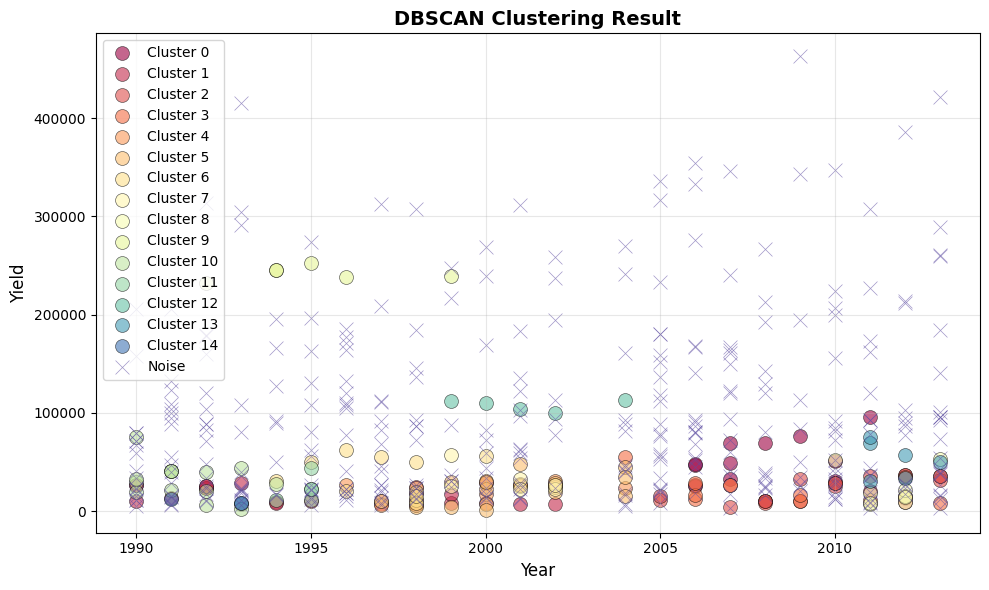

✓ DBSCAN plot đã vẽ


In [15]:
# Vẽ DBSCAN clusters
fig, ax = plt.subplots(figsize=(10, 6))

unique_labels = set(dbscan_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    class_member_mask = (dbscan_labels == label)
    
    if label == -1:
        marker = 'x'
        label_name = 'Noise'
    else:
        marker = 'o'
        label_name = f'Cluster {label}'
    
    ax.scatter(X_numeric_reset.loc[class_member_mask, feature_x],
              X_numeric_reset.loc[class_member_mask, feature_y],
              c=[color], label=label_name, marker=marker,
              s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

ax.set_xlabel(feature_x, fontsize=12)
ax.set_ylabel(feature_y, fontsize=12)
ax.set_title('DBSCAN Clustering Result', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ DBSCAN plot đã vẽ")

## 4. Comparison & Summary

In [16]:
# So sánh clustering algorithms
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("\n" + "="*80)
print("📊 CLUSTERING COMPARISON")
print("="*80)

# KMeans metrics
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"\n🎯 KMeans:")
print(f"   Silhouette Score: {kmeans_silhouette:.4f}")
print(f"   Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
print(f"   Number of clusters: {len(set(kmeans_labels))}")

# DBSCAN metrics
dbscan_n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
dbscan_n_noise = list(dbscan_labels).count(-1)

if dbscan_n_clusters > 0 and dbscan_n_clusters < len(set(dbscan_labels)):
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
    dbscan_davies_bouldin = davies_bouldin_score(X_scaled, dbscan_labels)
    
    print(f"\n🔍 DBSCAN:")
    print(f"   Silhouette Score: {dbscan_silhouette:.4f}")
    print(f"   Davies-Bouldin Index: {dbscan_davies_bouldin:.4f}")
    print(f"   Number of clusters: {dbscan_n_clusters}")
    print(f"   Noise points: {dbscan_n_noise}")


📊 CLUSTERING COMPARISON

🎯 KMeans:
   Silhouette Score: 0.2100
   Davies-Bouldin Index: 1.5820
   Number of clusters: 3

🔍 DBSCAN:
   Silhouette Score: -0.2204
   Davies-Bouldin Index: 1.5835
   Number of clusters: 15
   Noise points: 337


In [17]:
# Tóm tắt
print("\n" + "="*80)
print("✅ MINING & CLUSTERING HOÀN TẤT")
print("="*80)

print(f"\n📊 Summary:")
print(f"   • Association Rules Mining: {len(rules) if len(mining.rules) > 0 else 0} rules found")
print(f"   • KMeans Clustering: {len(set(kmeans_labels))} clusters")
print(f"   • DBSCAN Clustering: {dbscan_n_clusters} clusters, {dbscan_n_noise} noise points")


✅ MINING & CLUSTERING HOÀN TẤT

📊 Summary:
   • Association Rules Mining: 0 rules found
   • KMeans Clustering: 3 clusters
   • DBSCAN Clustering: 15 clusters, 337 noise points
